# 10 · Baselines — Consumo urbano anual por municipio

Objetivo: establecer la base de comparacion para los modelos de FASE VII con **5 modelos clasicos** de series temporales sobre el consumo urbano anual (`consumo_hm3`, municipio x anio).

- **Split temporal**: entrenamiento <= 2021, test 2022-2024 (horizonte h=3)
- Baselines: `naive`, `media`, `ets` (Holt con tendencia amortiguada), `gb_temporal` (GradientBoosting con features temporales), `arima` (auto-ARIMA, pmdarima)
- Metricas: MAE, MAPE (%), RMSE, R2 por municipio + agregadas
- Resultados: `results/10_baseline_metrics.csv` (formato normalizado: `modelo, cod_municipio, mae, mape, rmse, r2`)


In [1]:
import polars as pl
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from pmdarima import auto_arima
from sklearn.ensemble import GradientBoostingRegressor

sns.set_theme(style="whitegrid", palette="muted")
DATA = Path("data")
RESULTS = Path("results")
RESULTS.mkdir(exist_ok=True)

df = pl.read_csv(DATA / "abastecimiento_urbano_baleares.csv", infer_schema_length=None).select(["cod_municipio", "anio", "consumo_hm3"])
print("shape:", df.shape)


shape: (1675, 3)


In [2]:
TEST_START = 2022  # test: 2022-2024
H = 3               # horizonte de prediccion (anios)

years = sorted(df["anio"].unique().to_list())
series = {
    int(cod[0]): s.sort("anio")["consumo_hm3"].to_list()
    for cod, s in df.partition_by("cod_municipio", as_dict=True).items()
}
print(f"{len(series)} municipios | anios {years[0]}..{years[-1]} | test {TEST_START}..{years[-1]}")

def split(s):
    train = np.array([v for y, v in zip(years, s) if y < TEST_START], float)
    test = np.array([v for y, v in zip(years, s) if y >= TEST_START], float)
    return train, test


67 municipios | anios 2000..2024 | test 2022..2024


In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def metricas(test, pred):
    test, pred = np.asarray(test, float), np.asarray(pred, float)
    return dict(
        mae=float(mean_absolute_error(test, pred)),
        mape=float(np.mean(np.abs((test - pred) / test)) * 100),
        rmse=float(mean_squared_error(test, pred) ** 0.5),
        r2=float(r2_score(test, pred)),
    )

def particiones(g):
    g = g.sort("anio")
    train = g.filter(pl.col("anio") < TEST_START)
    test = g.filter(pl.col("anio") >= TEST_START)
    return train, test


In [4]:
# ── Baseline 1: Naive (persistencia del ultimo valor)
def naive_predict(train, h):
    return np.full(h, train[-1])

# ── Baseline 2: Media historica
def media_predict(train, h):
    return np.full(h, train.mean())

# ── Baseline 3: ETS / Holt (tendencia amortiguada, sin estacionalidad)
def ets_predict(train, h):
    m = ExponentialSmoothing(train, trend="add", damped_trend=True, initialization_method="estimated")
    fit = m.fit(optimized=True, remove_bias=True)
    return np.asarray(fit.forecast(h), float)


In [5]:
# ── Baseline 4: GradientBoosting temporal simple (por municipio, features: t, lag1, lag2, media movil 3)
def gb_predict(train, h):
    hist = list(train)
    preds = []
    for _ in range(h):
        X, y = [], []
        for i in range(3, len(hist)):
            X.append([i + 1, hist[i - 1], hist[i - 2], np.mean(hist[i - 3:i])])
            y.append(hist[i])
        if len(y) < 4:
            p = np.mean(hist)
        else:
            m = GradientBoostingRegressor(n_estimators=100, learning_rate=0.05, max_depth=2, random_state=42)
            m.fit(X, y)
            p = float(m.predict([[len(hist) + 1, hist[-1], hist[-2], np.mean(hist[-3:])]])[0])
        p = max(p, 0.0)
        preds.append(p)
        hist.append(p)
    return np.asarray(preds, float)


In [6]:
# ── Baseline 5: Auto-ARIMA (pmdarima, sin estacionalidad anual)
def arima_predict(train, h):
    m = auto_arima(train, seasonal=False, stepwise=True, d=1, max_p=2, max_q=2,
                   start_p=1, start_q=1, n_fits=10, suppress_warnings=True,
                   error_action="ignore", random_state=42)
    return np.asarray(m.predict(n_periods=h), float)


In [7]:
# ── Ejecutar los 5 baselines sobre los 67 municipios
modelos = {
    "naive": naive_predict,
    "media": media_predict,
    "ets": ets_predict,
    "gb_temporal": gb_predict,
    "arima": arima_predict,
}

filas = []
for nombre, fn in modelos.items():
    for cod, s in series.items():
        train, test = split(s)
        m = metricas(test, fn(train, H))
        filas.append({"modelo": nombre, "cod_municipio": cod, **m})

res = pd.DataFrame(filas)
res.to_csv(RESULTS / "10_baseline_metrics.csv", index=False)
print(res.groupby("modelo")[["mae", "mape", "rmse", "r2"]].mean().round(3))


               mae    mape   rmse       r2
modelo                                    
arima        0.221  12.198  0.235  -32.234
ets          0.209  11.673  0.224  -37.402
gb_temporal  0.213  11.745  0.226  -30.590
media        0.210  17.772  0.219 -131.101
naive        0.212  11.557  0.226  -27.043


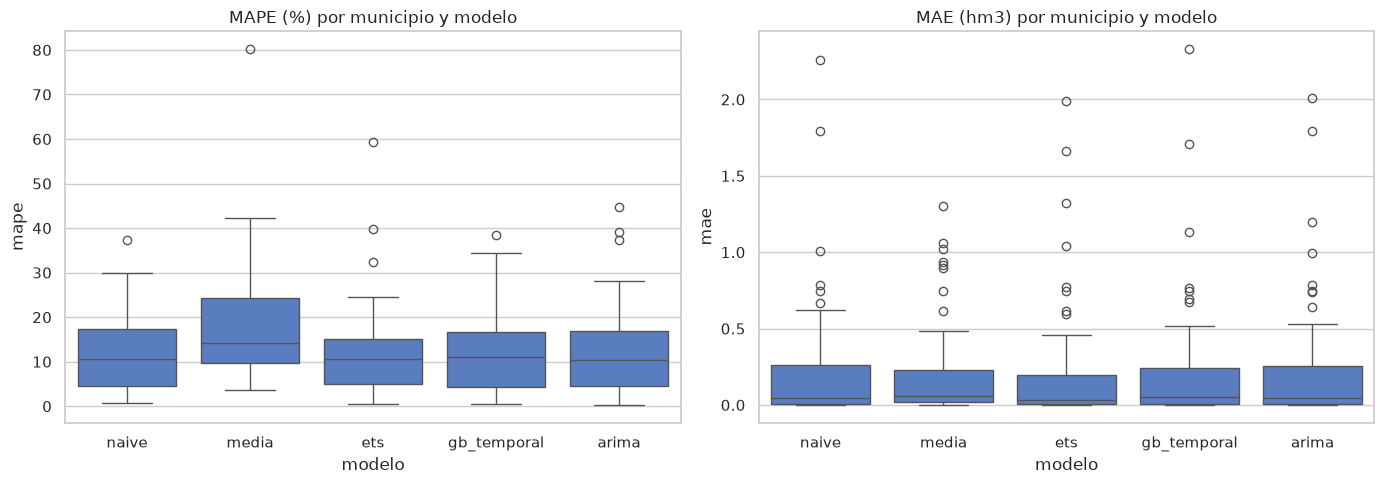

In [8]:
# ── Comparativa grafica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=res, x="modelo", y="mape", ax=axes[0])
axes[0].set_title("MAPE (%) por municipio y modelo")
sns.boxplot(data=res, x="modelo", y="mae", ax=axes[1])
axes[1].set_title("MAE (hm3) por municipio y modelo")
plt.tight_layout()
plt.show()


In [9]:
# ── Mejor modelo por municipio (min MAPE)
best = res.loc[res.groupby("cod_municipio")["mape"].idxmin()]
print(best.groupby("modelo").size().rename("municipios ganados").sort_values(ascending=False))


modelo
ets            15
arima          13
gb_temporal    13
media          13
naive          13
Name: municipios ganados, dtype: int64


**Conclusiones del baseline**

- Con series anuales cortas y sin estacionalidad, lo esperado es que `naive` y `media` sean duros de batir; ETS/ARIMA suelen quedar cerca (tendencia amortiguada -> practicamente naive con drift).
- `gb_temporal` aporta la unica referencia con variables explicativas (lags y tendencia) — es el puente hacia los modelos con features externas (11-13).
- Estos resultados son la cota a superar: si los modelos con features (IPH, ocupacion, lluvia) no mejoran el MAPE del baseline, las features no aportan senal predictiva sobre el consumo anual.
